date_served  age_group  
1/1/18       0-18 years     0.155172
             19-24 years    0.196721
             24-30 years    0.105263
             30-36 years    0.040816
             36-45 years    0.042553
                              ...   
1/9/18       24-30 years    0.152174
             30-36 years    0.090909
             36-45 years    0.093023
             45-55 years    0.068182
             55+ years      0.102564
Name: user_id, Length: 217, dtype: float64
age_group    0-18 years  19-24 years  24-30 years  30-36 years  36-45 years  \
date_served                                                                   
1/1/18         0.155172     0.196721     0.105263     0.040816     0.042553   
1/10/18        0.100000     0.216667     0.129630     0.068182     0.088889   
1/11/18        0.085106     0.187500     0.173913     0.000000     0.000000   

age_group    45-55 years  55+ years  
date_served                          
1/1/18          0.022222   0.086957  
1/10/18        

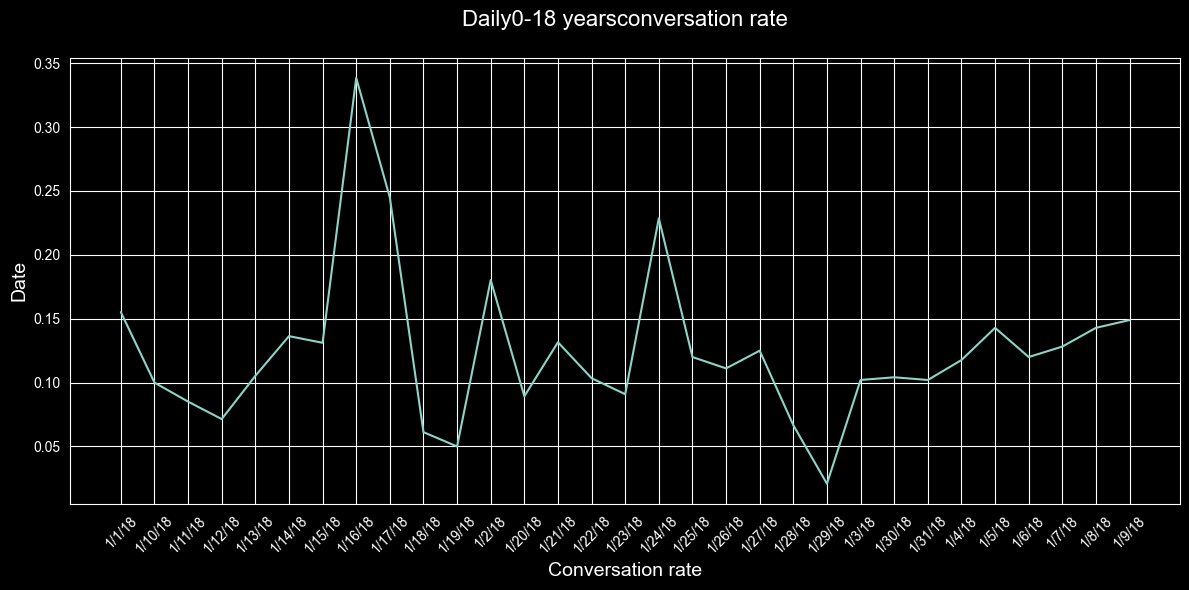

<Figure size 640x480 with 0 Axes>

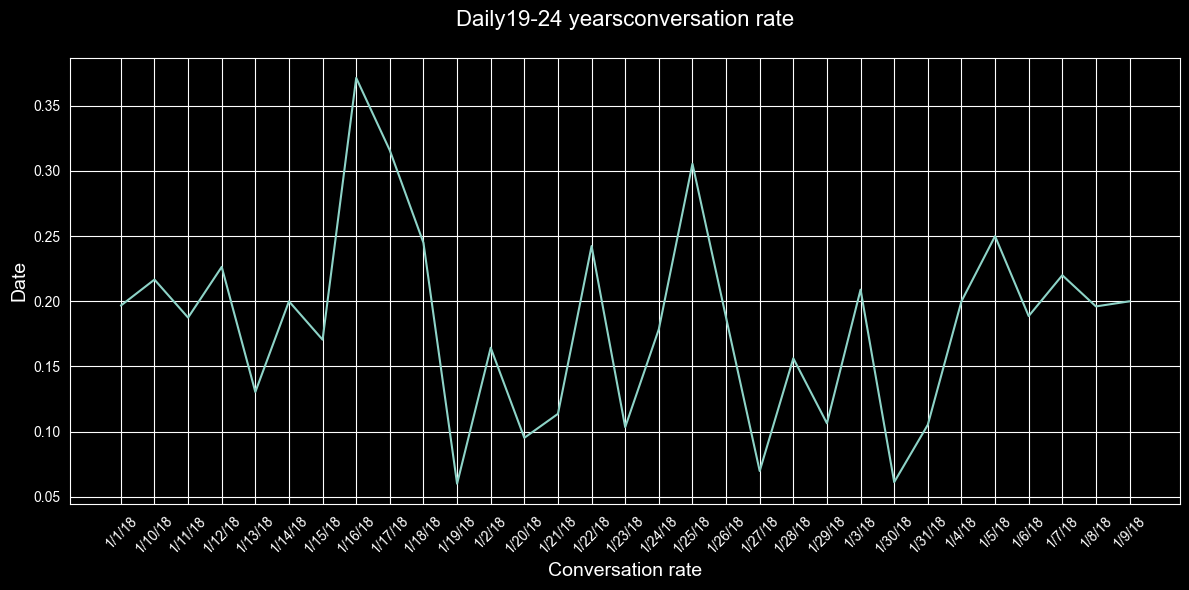

<Figure size 640x480 with 0 Axes>

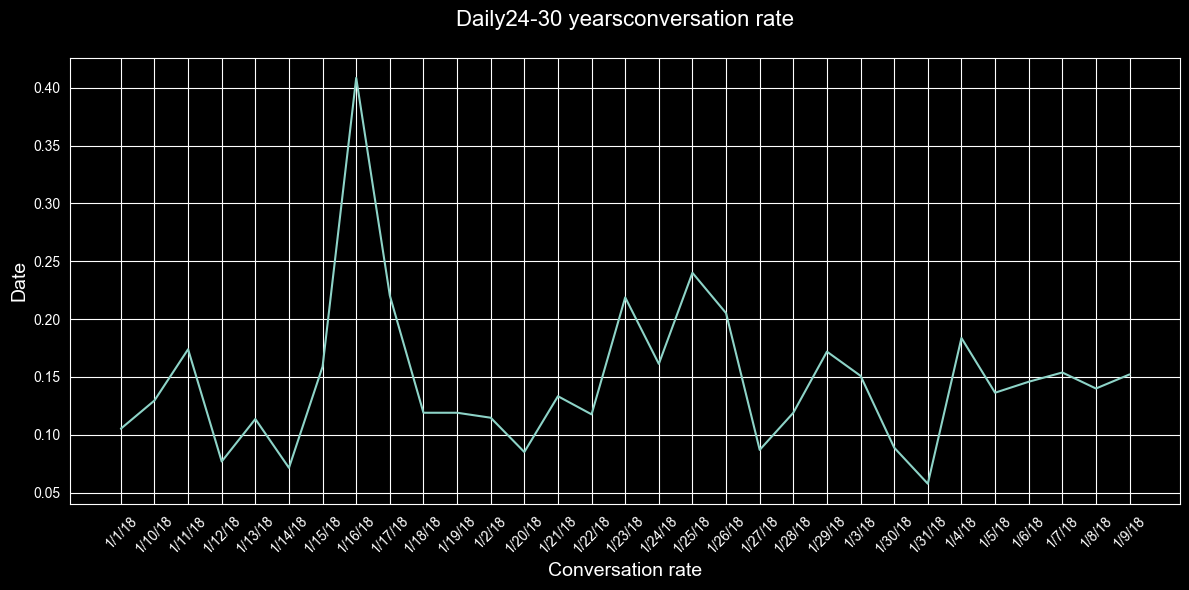

<Figure size 640x480 with 0 Axes>

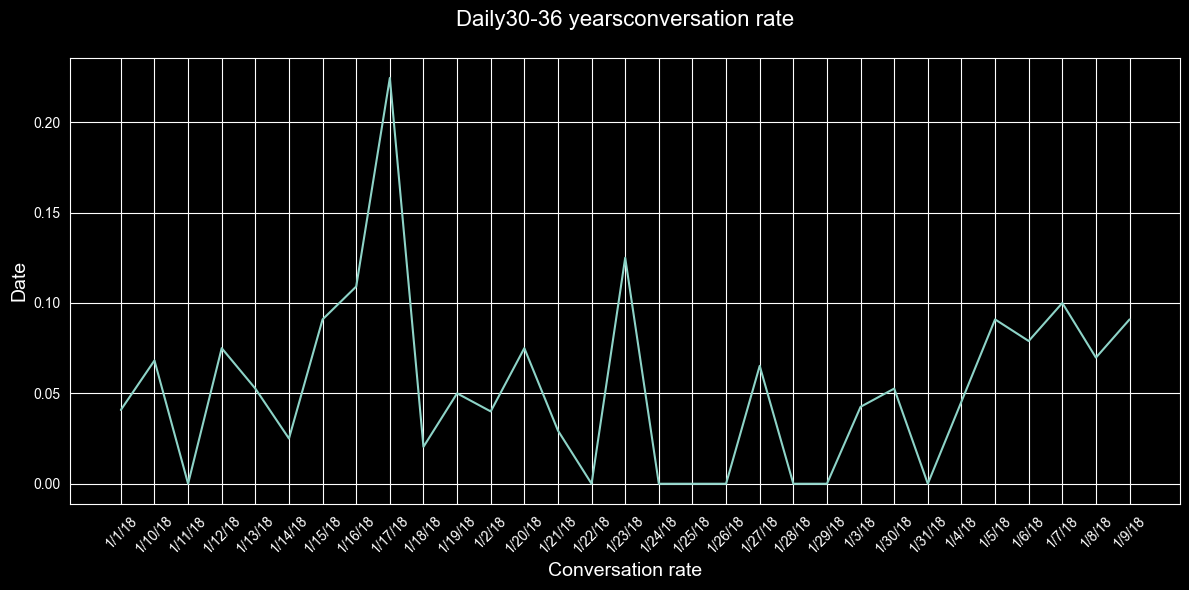

<Figure size 640x480 with 0 Axes>

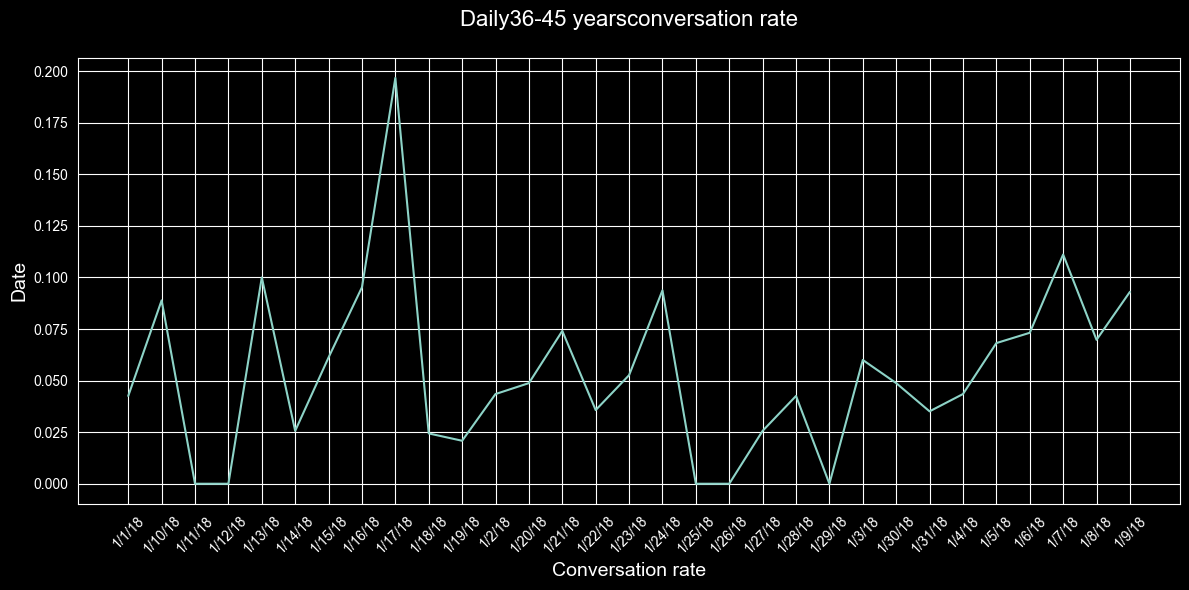

<Figure size 640x480 with 0 Axes>

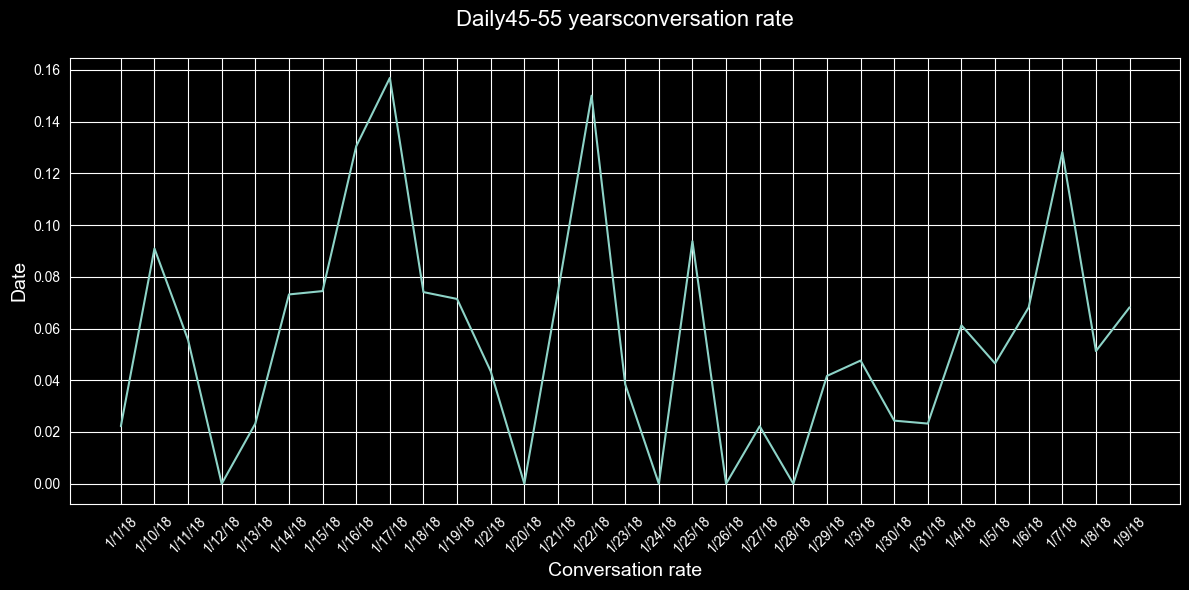

<Figure size 640x480 with 0 Axes>

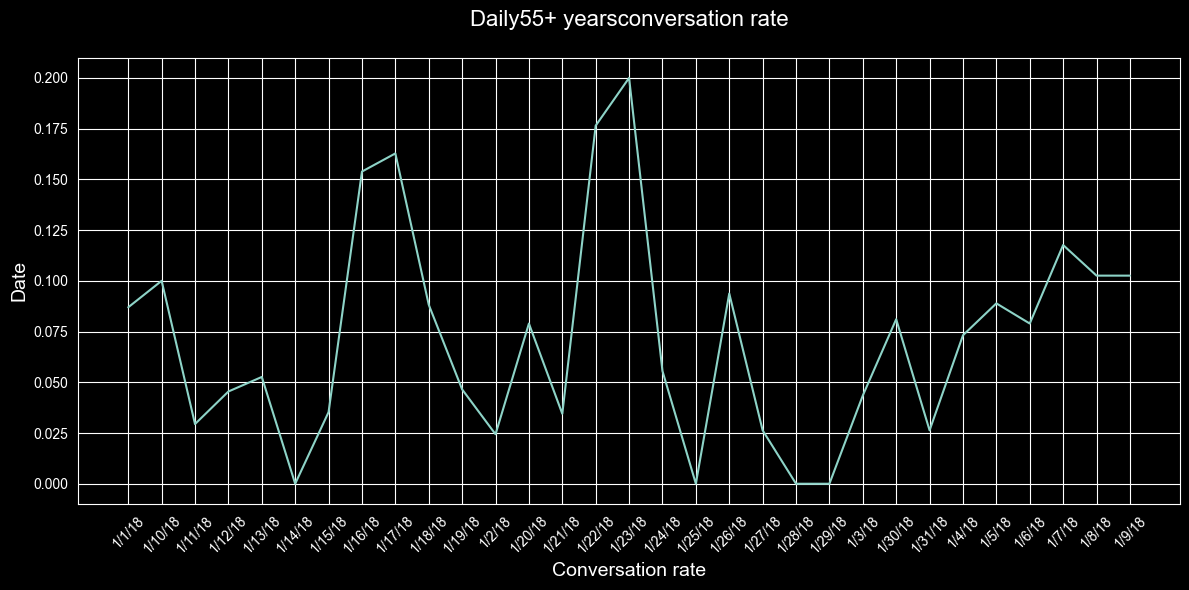

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('marketing_r.csv', sep=",")


def conversion_rate(dataframe, columns_name):
    column_conv = dataframe[dataframe['converted'] == True].groupby(columns_name)['user_id'].nunique()
    column_total = dataframe.groupby(columns_name)['user_id'].nunique()

    conversion_rate = column_conv / column_total
    conversion_rate = conversion_rate.fillna(0)  # NaN wypełniamy zerami

    return conversion_rate


def plotting_conv(dataframe):
    for column in dataframe:
        plt.figure(figsize=(12, 6))
        plt.plot(dataframe.index, dataframe[column])

        plt.title("Daily" + str(column) + "conversation rate\n", size=16)
        plt.xlabel("Conversation rate", size=14)
        plt.ylabel("Date", size=14)
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()
        plt.clf()  # czyści wykres


if __name__ == '__main__':
    age_group_conv = conversion_rate(df, ['date_served', 'age_group'])
    print(age_group_conv)
    # date_served  age_group
    # 1/1/18       0-18 years     0.155172
    #              19-24 years    0.196721
    #              24-30 years    0.105263
    #              30-36 years    0.040816
    #              36-45 years    0.042553

    age_group_conv_df = pd.DataFrame(age_group_conv.unstack(level=1))
    print(age_group_conv_df.head(3))
    plotting_conv(age_group_conv_df)
